# IMPORT LIBRARY

In [41]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# LOAD DATASET

In [42]:
df = pd.read_csv("student_habits_performance.csv")

print("="*50)
print("DATASET INFORMATION")
print("="*50)

print(df.head())
print("\nShape :", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

DATASET INFORMATION
  student_id  age  gender  study_hours_per_day  social_media_hours  \
0      S1000   23  Female                  0.0                 1.2   
1      S1001   20  Female                  6.9                 2.8   
2      S1002   21    Male                  1.4                 3.1   
3      S1003   23  Female                  1.0                 3.9   
4      S1004   19  Female                  5.0                 4.4   

   netflix_hours part_time_job  attendance_percentage  sleep_hours  \
0            1.1            No                   85.0          8.0   
1            2.3            No                   97.3          4.6   
2            1.3            No                   94.8          8.0   
3            1.0            No                   71.0          9.2   
4            0.5            No                   90.9          4.9   

  diet_quality  exercise_frequency parental_education_level internet_quality  \
0         Fair                   6                   Maste

# FEATURE AND TARGET

In [43]:

X = df.drop(["student_id", "exam_score"], axis=1)

y = df["exam_score"]

# NUMERIC AND CATEGORICAL

In [44]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print("\nNumeric Features:")
print(list(numeric_features))

print("\nCategorical Features:")
print(list(categorical_features))


Numeric Features:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']

Categorical Features:
['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


# PREPROCESSING

In [45]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# SPLIT DATA

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# TRAINING

In [47]:
pipeline.fit(X_train, y_train)

print("\nTraining selesai!")


Training selesai!


# PREDIKSI

In [48]:
y_pred = pipeline.predict(X_test)

# FEATURE IMPORTANCE

In [49]:
ohe = pipeline.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .named_steps["onehot"]

encoded_features = ohe.get_feature_names_out(
    categorical_features
)

all_features = (
    list(numeric_features)
    + list(encoded_features)
)

importances = pipeline.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n")
print("="*50)
print("TOP 15 FEATURE IMPORTANCE")
print("="*50)

print(feature_importance.head(15))



TOP 15 FEATURE IMPORTANCE
                              Feature  Importance
1                 study_hours_per_day    0.713652
7                mental_health_rating    0.105288
2                  social_media_hours    0.038448
5                         sleep_hours    0.035565
3                       netflix_hours    0.033314
6                  exercise_frequency    0.024568
4               attendance_percentage    0.018725
0                                 age    0.007912
14                  diet_quality_Good    0.002122
16  parental_education_level_Bachelor    0.002118
20              internet_quality_Good    0.001784
19           internet_quality_Average    0.001607
8                       gender_Female    0.001593
18    parental_education_level_Master    0.001557
13                  diet_quality_Fair    0.001553


# CONTOH PREDIKSI

In [50]:
new_student = pd.DataFrame({
    "age":[20],
    "gender":["Male"],
    "study_hours_per_day":[5],
    "social_media_hours":[2],
    "netflix_hours":[1],
    "part_time_job":["No"],
    "attendance_percentage":[90],
    "sleep_hours":[7],
    "diet_quality":["Good"],
    "exercise_frequency":[3],
    "parental_education_level":["Bachelor"],
    "internet_quality":["Good"],
    "mental_health_rating":[8],
    "extracurricular_participation":["Yes"]
})

prediction = pipeline.predict(new_student)

print("\n")
print("="*50)
print("PREDIKSI NILAI UJIAN")
print("="*50)

print(f"Prediksi Exam Score: {prediction[0]:.2f}")




PREDIKSI NILAI UJIAN
Prediksi Exam Score: 95.40


# PERBANDINGAN BEBERAPA MODEL

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        random_state=42
    )
}

results = []

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2 Score": round(r2, 4)
    })

results_df = pd.DataFrame(results)

print("\n")
print("="*70)
print("PERBANDINGAN MODEL")
print("="*70)
print(results_df.sort_values(
    by="R2 Score",
    ascending=False
))



PERBANDINGAN MODEL
               Model   MAE  RMSE  R2 Score
0  Linear Regression  4.19  5.15    0.8965
2      Random Forest  4.99  6.24    0.8484
1      Decision Tree  7.09  9.09    0.6781


# PERBANDINGAN R2 SCORE

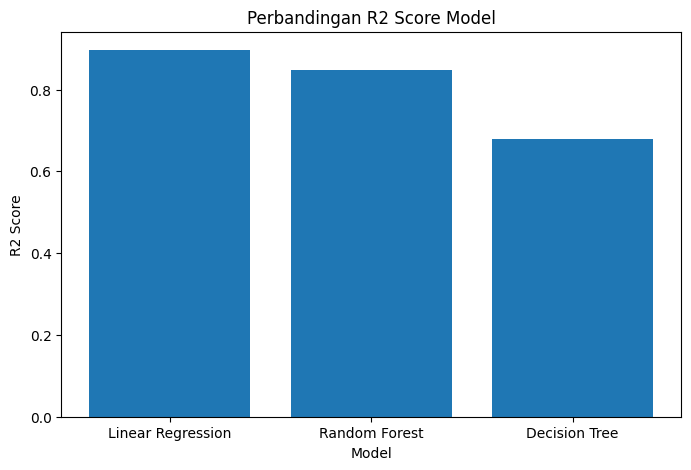

In [52]:
results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.title("Perbandingan R2 Score Model")
plt.ylabel("R2 Score")
plt.xlabel("Model")
plt.savefig("r2score.png")
plt.show()

# CROSS VALIDATION

In [53]:
pipeline_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

scores = cross_val_score(
    pipeline_lr,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation R2:")
print(scores)
print("Average R2:", scores.mean())

Cross Validation R2:
[0.89189841 0.91219394 0.88614259 0.90286889 0.88545938]
Average R2: 0.895712643221518


# ACTUAL VS PREDICTED

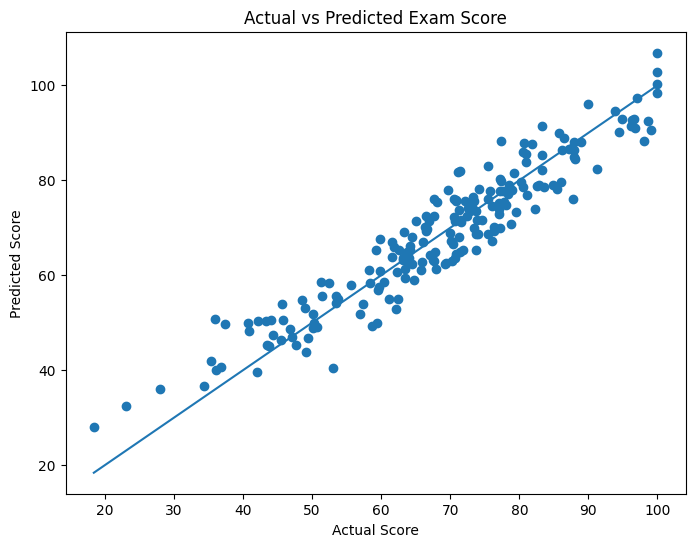

In [54]:
pipeline_lr.fit(X_train, y_train)

pred = pipeline_lr.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Exam Score")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.savefig("ActualvsPredicted.png")
plt.show()

Penelitian ini bertujuan untuk memprediksi nilai ujian siswa (exam_score) berdasarkan kebiasaan belajar, kehadiran, kualitas tidur, kesehatan mental, penggunaan media sosial, dan faktor lainnya menggunakan beberapa algoritma Machine Learning.

Model yang diuji:

Linear Regression
Decision Tree Regressor
Random Forest Regressor

Hasil evaluasi menunjukkan:

Model	MAE	RMSE	R² Score
Linear Regression	4.19	5.15	0.8965
Random Forest	4.99	6.24	0.8484
Decision Tree	7.09	9.09	0.6781
Analisis Hasil

Berdasarkan nilai evaluasi, Linear Regression memberikan performa terbaik dibandingkan model lainnya dengan:

MAE terendah (4.19)
RMSE terendah (5.15)
R² tertinggi (0.8965)

Nilai R² sebesar 0.8965 menunjukkan bahwa model mampu menjelaskan sekitar 89,65% variasi nilai ujian siswa berdasarkan fitur-fitur yang tersedia pada dataset.

Hasil ini mengindikasikan bahwa hubungan antara variabel-variabel seperti jam belajar, persentase kehadiran, kualitas tidur, dan kesehatan mental terhadap nilai ujian cenderung bersifat linear, sehingga model Linear Regression mampu menangkap pola data dengan lebih baik dibandingkan model berbasis pohon keputusan.

Kesimpulan Akhir

Model Linear Regression dipilih sebagai model terbaik untuk prediksi nilai ujian siswa karena menghasilkan akurasi tertinggi dan tingkat kesalahan prediksi paling rendah. Model ini dapat digunakan sebagai dasar untuk menganalisis faktor-faktor yang mempengaruhi performa akademik siswa serta membantu institusi pendidikan dalam melakukan evaluasi dan pengambilan keputusan berbasis data.